In [1]:
!pip install deepface opencv-python pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00


In [2]:
from deepface import DeepFace
import cv2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

26-03-19 12:28:03 - Directory /root/.deepface has been created
26-03-19 12:28:03 - Directory /root/.deepface/weights has been created


In [3]:
folder = "/content/faces"

In [4]:
data = []

for img_name in os.listdir(folder):
    img_path = os.path.join(folder, img_name)

    try:
        result = DeepFace.analyze(
            img_path,
            actions=['emotion', 'gender', 'age', 'race'],
            enforce_detection=False
        )[0]

        # Основные параметры
        gender = result['dominant_gender']
        age = result['age']
        race = result['dominant_race']
        emotion = result['dominant_emotion']

        # Вероятности эмоций
        emotions = result['emotion']

        data.append([
            img_name,
            gender,
            age,
            race,
            emotion,
            emotions['happy'],
            emotions['neutral'],
            emotions['sad'],
            emotions['angry'],
            emotions['fear'],
            emotions['surprise'],
            emotions['disgust']
        ])

    except:
        continue

Action: emotion:   0%|          | 0/4 [00:00<?, ?it/s]

26-03-19 12:32:47 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 113MB/s]
Action: gender:  25%|██▌       | 1/4 [00:00<00:02,  1.29it/s] 

26-03-19 12:32:50 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 11.0M/537M [00:00<00:06, 77.9MB/s]
  4%|▍         | 22.0M/537M [00:00<00:05, 92.1MB/s]
  7%|▋         | 35.1M/537M [00:00<00:04, 108MB/s] 
 10%|▉         | 53.0M/537M [00:00<00:04, 109MB/s]
 12%|█▏        | 65.5M/537M [00:00<00:04, 112MB/s]
 15%|█▌        | 82.8M/537M [00:00<00:03, 130MB/s]
 18%|█▊        | 96.5M/537M [00:00<00:03, 113MB/s]
 20%|██        | 109M/537M [00:00<00:03, 109MB/s] 
 22%|██▏       | 120M/537M [00:01<00:04, 100MB/s]
 24%|██▍       | 131M/537M [00:01<00:04, 96.2MB/s]
 28%|██▊       | 148M/537M [00:01<00:03, 116MB/s] 
 30%|███       | 162M/537M [00:01<00:03, 122MB/s]
 33%|███▎      | 175M/537M [00:01<00:02, 123MB/s]
 35%|███▌      | 189M/537M [00:01<00:03, 106MB/s]
 38%|███▊      | 205M/537M [00:01<00:02, 119MB/s]
 41%|████      | 219M/537M [0

26-03-19 12:33:04 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...



  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 11.5M/539M [00:00<00:04, 114MB/s]
  6%|▌         | 29.9M/539M [00:00<00:03, 154MB/s]
  9%|▉         | 48.8M/539M [00:00<00:02, 169MB/s]
 12%|█▏        | 66.1M/539M [00:00<00:02, 168MB/s]
 15%|█▌        | 83.4M/539M [00:00<00:02, 163MB/s]
 19%|█▊        | 100M/539M [00:00<00:02, 150MB/s] 
 21%|██▏       | 115M/539M [00:00<00:03, 132MB/s]
 24%|██▍       | 129M/539M [00:00<00:03, 129MB/s]
 27%|██▋       | 145M/539M [00:01<00:02, 138MB/s]
 30%|██▉       | 159M/539M [00:01<00:03, 110MB/s]
 32%|███▏      | 171M/539M [00:01<00:03, 103MB/s]
 34%|███▍      | 182M/539M [00:03<00:19, 18.0MB/s]
 38%|███▊      | 205M/539M [00:03<00:11, 29.5MB/s]
 42%|████▏     | 228M/539M [00:03<00:07, 44.1MB/s]
 46%|████▋     | 250M/539M [00:03<00:04, 60.2MB/s]
 50%|████▉     | 267M/539M [00:03<00:03, 71.5MB/s]
 53%|█████▎    | 283M/539M [00:04<00:03, 79.8MB/s]
 56%|█████▋    | 304M/539M [00:04<00:02, 101MB/s] 
 60%|██████    | 323M/539M [00:04<00:01, 11

26-03-19 12:33:20 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 11.0M/537M [00:00<00:06, 80.6MB/s]
  5%|▍         | 26.7M/537M [00:00<00:04, 115MB/s] 
  7%|▋         | 38.8M/537M [00:00<00:04, 117MB/s]
  9%|▉         | 50.9M/537M [00:00<00:04, 110MB/s]
 12%|█▏        | 62.4M/537M [00:00<00:04, 110MB/s]
 14%|█▍        | 73.9M/537M [00:00<00:04, 97.1MB/s]
 16%|█▌        | 84.4M/537M [00:00<00:04, 98.2MB/s]
 18%|█▊        | 94.9M/537M [00:00<00:04, 97.9MB/s]
 20%|█▉        | 105M/537M [00:01<00:04, 96.7MB/s] 
 22%|██▏       | 116M/537M [00:01<00:04, 92.7MB/s]
 24%|██▎       | 126M/537M [00:01<00:04, 92.5MB/s]
 25%|██▌       | 137M/537M [00:01<00:04, 93.2MB/s]
 27%|██▋       | 147M/537M [00:01<00:04, 94.5MB/s]
 29%|██▉       | 158M/537M [00:01<00:04, 88.1MB/s]
 31%|███▏      | 168M/537M [00:01<00:04, 86.6MB/s]
 33%|███▎      

In [7]:
columns = [
    "image",
    "gender",
    "age",
    "race",
    "dominant_emotion",
    "happy",
    "neutral",
    "sad",
    "angry",
    "fear",
    "surprise",
    "disgust"
]

df = pd.DataFrame(data, columns=columns)
df.head()

,image,gender,age,race,dominant_emotion,happy,neutral,sad,angry,fear,surprise,disgust
0,000097.jpg,Woman,31,white,fear,0.016909,16.278610,5.043533e+00,2.909659e+01,4.720249e+01,2.284388e+00,7.748678e-02
1,000127.jpg,Man,50,middle eastern,happy,89.900185,0.322463,6.131423e-01,2.597633e+00,6.218519e+00,3.300848e-01,1.797164e-02
2,000181.jpg,Man,25,asian,happy,99.999825,0.000182,7.514607e-11,6.040918e-12,7.060871e-14,6.872183e-11,8.636366e-19
3,000042.jpg,Woman,33,white,happy,81.127884,18.824314,1.567014e-02,2.242545e-04,2.236115e-02,9.541921e-03,2.202626e-07
4,000087.jpg,Woman,25,white,happy,97.066521,2.932435,7.758362e-05,4.461089e-07,7.943140e-07,9.686745e-04,4.313901e-11


In [8]:
df.to_csv("analysis_results.csv", index=False)

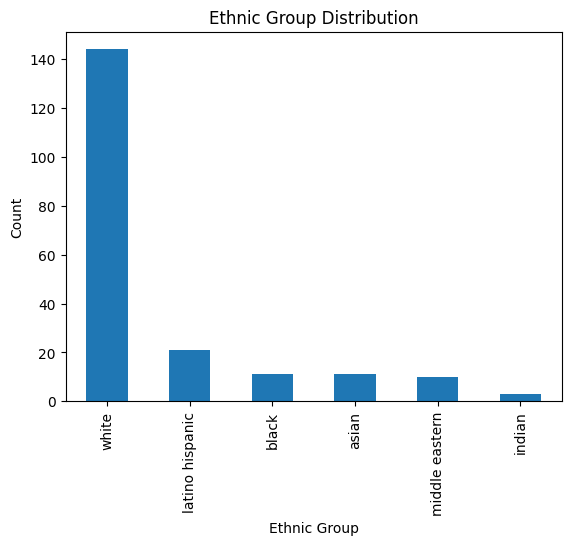

In [9]:
plt.figure()
df["race"].value_counts().plot(kind="bar")
plt.title("Ethnic Group Distribution")
plt.xlabel("Ethnic Group")
plt.ylabel("Count")
plt.show()

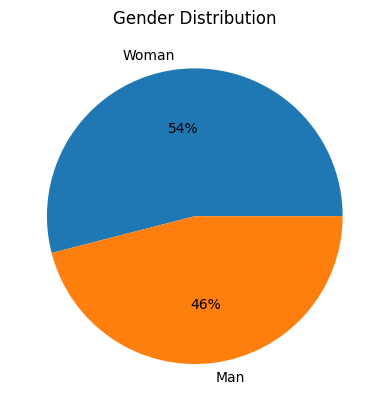

In [10]:
plt.figure()
df["gender"].value_counts().plot(kind="pie", autopct="%1.0f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

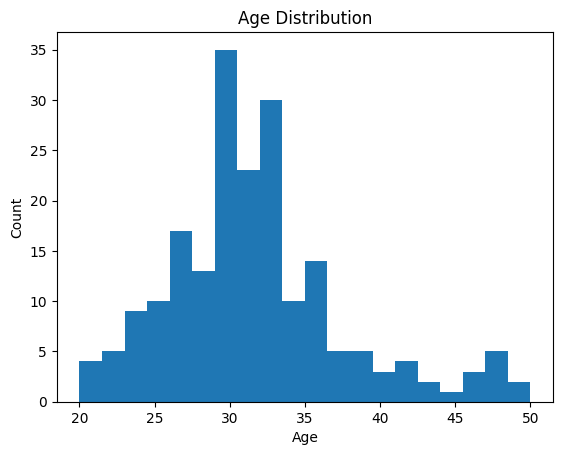

In [11]:
plt.figure()
df["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

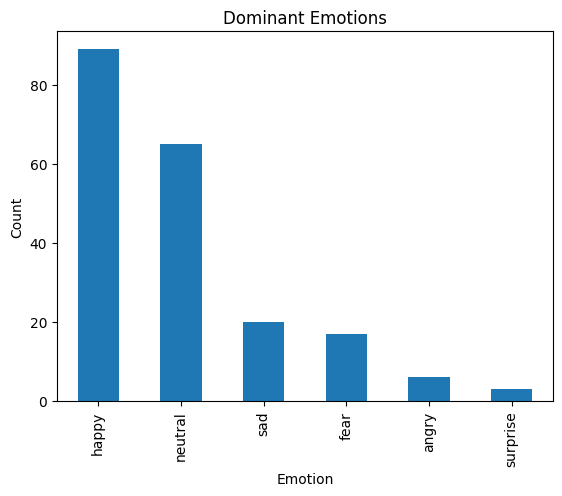

In [12]:
plt.figure()
df["dominant_emotion"].value_counts().plot(kind="bar")
plt.title("Dominant Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

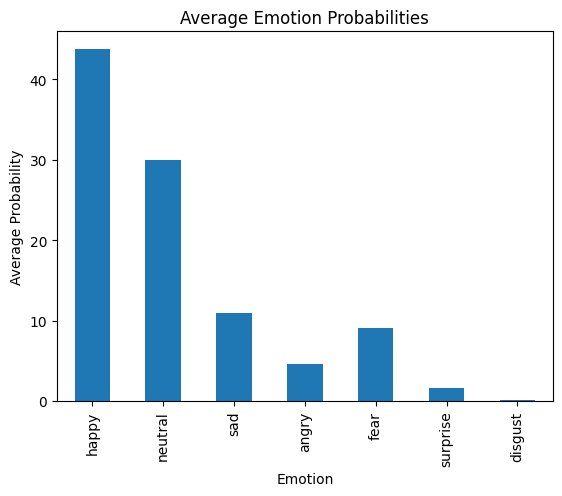

In [13]:
emotion_cols = ["happy","neutral","sad","angry","fear","surprise","disgust"]
avg_emotions = df[emotion_cols].mean()

plt.figure()
avg_emotions.plot(kind="bar")
plt.title("Average Emotion Probabilities")
plt.xlabel("Emotion")
plt.ylabel("Average Probability")
plt.show()

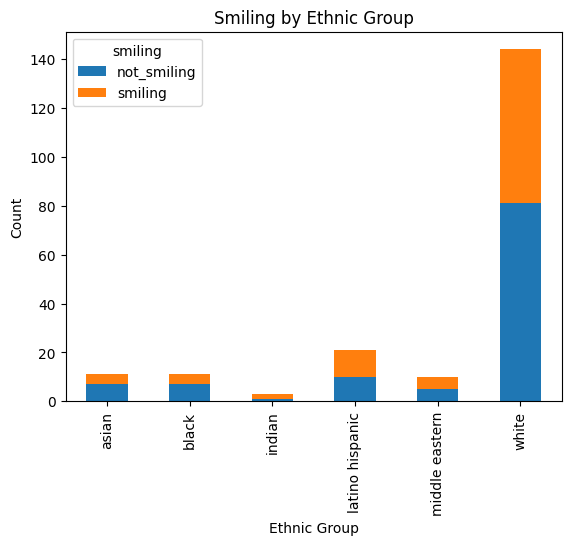

In [14]:
df["smiling"] = df["dominant_emotion"].apply(lambda x: "smiling" if x=="happy" else "not_smiling")

smile_by_race = pd.crosstab(df["race"], df["smiling"])

smile_by_race.plot(kind="bar", stacked=True)
plt.title("Smiling by Ethnic Group")
plt.xlabel("Ethnic Group")
plt.ylabel("Count")
plt.show()

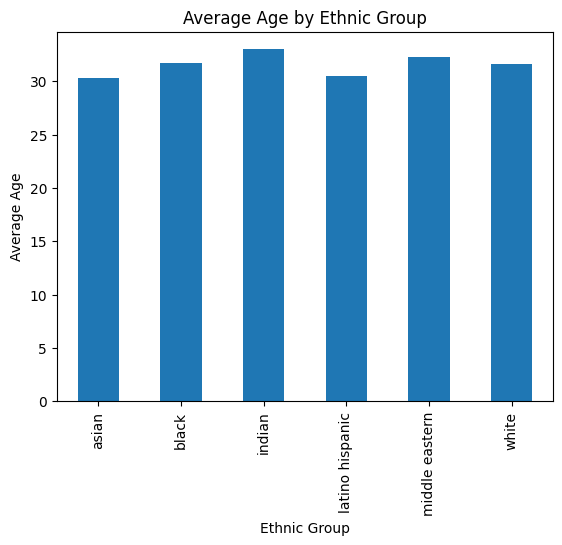

In [15]:
avg_age = df.groupby("race")["age"].mean()

plt.figure()
avg_age.plot(kind="bar")
plt.title("Average Age by Ethnic Group")
plt.xlabel("Ethnic Group")
plt.ylabel("Average Age")
plt.show()

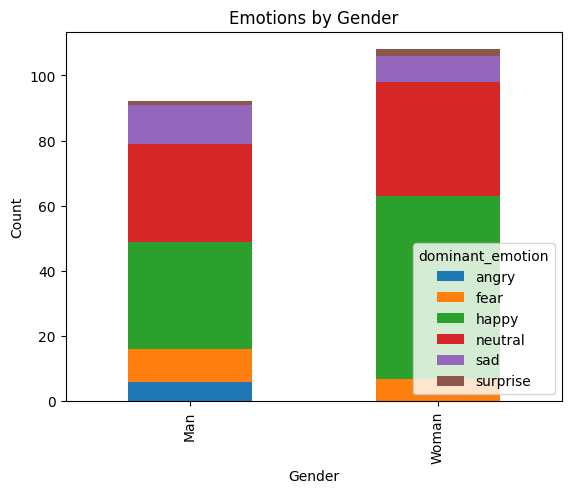

In [16]:
gender_emotion = pd.crosstab(df["gender"], df["dominant_emotion"])

gender_emotion.plot(kind="bar", stacked=True)
plt.title("Emotions by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()